In [1]:
import json
import dataclasses

import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [2]:
@dataclasses.dataclass
class CohesinData:
    trajectory: list[tuple[int, int | None]]
    birth_frame: int

In [3]:
config_id = 75
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    config = json.loads(store["metadata/config_source"][()])
    config_used = json.loads(store["metadata/config"][()])

    production_overrides = config_used["sampling"]["phases"][-1]
    production_name = production_overrides["name"]
    phase_store = store["phases"][production_name]

    positions_history = []
    cohesins_history: dict[int, CohesinData] = {}

    for frame_index, step_key in enumerate(phase_store[".steps"]):
        sample = phase_store[step_key]

        positions = sample["positions"][:]
        positions_history.append(positions)

        for cohesin_id, (loaded_site, captured_site) in zip(
            sample["captures/ids"],
            sample["captures/sites"],
        ):
            if cohesin_id not in cohesins_history:
                cohesins_history[cohesin_id] = CohesinData(
                    trajectory=[],
                    birth_frame=frame_index,
                )
            if captured_site == loaded_site:
                captured_site = None
            cohesins_history[cohesin_id].trajectory.append(
                (loaded_site, captured_site)
            )

    positions_history = np.array(positions_history)

cohesin_ids = list(cohesins_history.keys())
frame_count = len(positions_history)

In [4]:
chain_used, = config_used["chains"]
chain_length = chain_used["length"]
default_valency = config_used["association"]["valency"]

selector_a = np.full(chain_length, False)
for feature in chain_used.get("association_features", []):
    is_a = False
    match feature:
        case {"valency": valency}:
            is_a = (valency < default_valency)

        case {"association": _} | {"dissociation": _}:
            assoc = feature.get("association", 1)
            dissoc = feature.get("dissociation", 1)
            is_a = (assoc < dissoc)

    if is_a:
        site = feature["site"]
        start = site["start"]
        end = site["end"]
        selector_a[start:end] = True

selector_b = ~selector_a

In [5]:
print("phi ", selector_a.mean())

phi  0.115


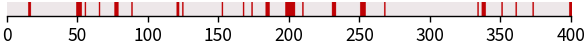

In [6]:
fig, ax = plt.subplots(figsize=(3.0, 0.3))

ax.matshow(
    selector_a[None, :],
    origin="lower",
    extent=[0, chain_length, 1, 0],
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap=colorcet.m_coolwarm,
    interpolation="kaiser",
)
set_axis(ax, "bottom")

pass

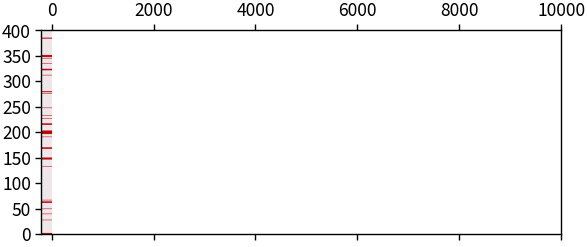

In [7]:
sm = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(0, len(cohesin_ids)),
    cmap=colorcet.m_rainbow,
)

fig, ax = plt.subplots(figsize=(3.0, 1.3))

for i, cohesin_data in enumerate(cohesins_history.values()):
    color = sm.to_rgba(i)
    x = np.arange(len(cohesin_data.trajectory)) + cohesin_data.birth_frame
    y = [i for i, j in cohesin_data.trajectory]
    ax.plot(x, y, color=color)
    y = [j for i, j in cohesin_data.trajectory]
    ax.scatter(x, y, s=0.2, ec="none", fc=color)

ax.autoscale(False)

left_margin = frame_count * 0.02

ax.matshow(
    selector_a[:, None],
    origin="lower",
    extent=[-left_margin, 0, chain_length, 0],
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap=colorcet.m_coolwarm,
    interpolation="kaiser",
)

ax.set_xlim(-left_margin, frame_count)
ax.set_ylim(0, chain_length)

pass

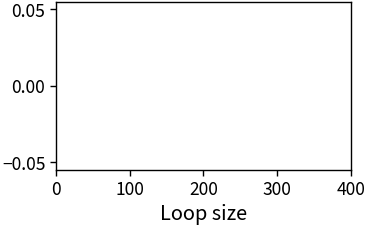

In [8]:
loop_sizes = []
for history in cohesins_history.values():
    loop_sizes.extend(abs(i - j) for i, j in history.trajectory if j is not None)

fig, ax = plt.subplots(figsize=(1.9, 1.2))
ax.hist(loop_sizes, bins=np.arange(0, chain_length))
ax.set_xlim(0, chain_length)
ax.set_xlabel("Loop size")
ax.set_ylabel("")
pass

In [9]:
def drop_keys(d: dict, *arg: any) -> dict:
    return {key: value for key, value in d.items() if key not in arg}

In [10]:
sampling_config = config["sampling"]
production_config = {**drop_keys(sampling_config, "phases"), **production_overrides}

frame_interval = production_config["timestep"] * production_config["sampling_interval"]
diffusion_timescale = 1 / config["chain"]["monomer_mobility"]

In [11]:
def collect_msds(
    paths: np.ndarray,  # (time, particle, dim)
    lag: int,
) -> np.ndarray:
    squared_dists = np.zeros((lag, paths.shape[1]))
    for t in range(0, paths.shape[0] - lag):
        delta = paths[t:t + lag] - paths[t]
        squared_dists += (delta ** 2).sum(-1)
    return squared_dists / (paths.shape[0] - lag)


def subtract_centroid(paths: np.ndarray) -> np.ndarray:
    return paths - paths.mean(axis=1, keepdims=True)


def compute_rg(positions: np.ndarray) -> np.ndarray:
    centroid = positions.mean(axis=-2, keepdims=True)
    return np.sqrt((positions - centroid).var(axis=-2).sum(axis=-1))

In [12]:
tracked_pairs = [100], [300]
pair_lag_frames = 7

tracked_paths = (
    positions_history[:, tracked_pairs[0], :] -
    positions_history[:, tracked_pairs[1], :]
)
pair_msd = collect_msds(tracked_paths, lag=pair_lag_frames).mean(1)

x = frame_interval * np.arange(len(pair_msd))
y = pair_msd
pair_alpha, pair_beta = fit_power_law(x, y)

In [13]:
rg_history_a = compute_rg(positions_history[:, :200, :])
rg_history_b = compute_rg(positions_history[:, 200:, :])

mean_rg_a = rg_history_a.mean()
mean_rg_b = rg_history_b.mean()
print(mean_rg_a)
print(mean_rg_b)

3.896919
3.9565935


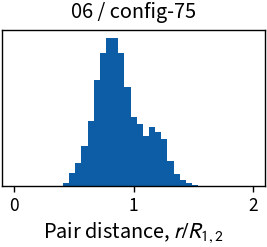

In [14]:
distances = np.linalg.norm(tracked_paths, axis=2)[:, 0] / (mean_rg_a + mean_rg_b)
distance_bins = np.linspace(0, 2, num=40)

fig, ax = plt.subplots(figsize=(1.4, 1.3))

ax.hist(distances, bins=distance_bins)

ax.set_yticks([])

ax.set_xlabel(r"Pair distance, $ r / R_{1,2} $")
ax.set_title(f"06 / config-{config_id}")

pass

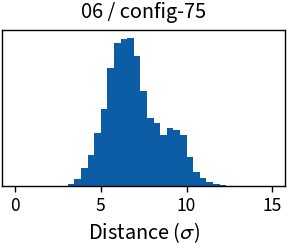

In [15]:
distances = np.linalg.norm(tracked_paths, axis=2)[:, 0]
distance_bins = np.linspace(0, 15, num=40)

fig, ax = plt.subplots(figsize=(1.5, 1.3))

ax.hist(distances, bins=distance_bins)

ax.set_yticks([])

ax.set_xlabel(r"Distance ($ \sigma $)")
ax.set_title(f"06 / config-{config_id}")

pass

In [16]:
lag_frames = 7
lag_time = lag_frames * frame_interval

#paths = subtract_centroid(positions_history)
paths = positions_history

msd = collect_msds(paths, lag=lag_frames).mean(1)

x = frame_interval * np.arange(len(msd))
y = msd
alpha, beta = fit_power_law(x, y)

if selector_a.sum() > 0:
    y = msd_a = collect_msds(paths[:, selector_a], lag=lag_frames).mean(1)
    alpha_a, beta_a = fit_power_law(x, y)

if selector_b.sum() > 0:
    y = msd_b = collect_msds(paths[:, selector_b], lag=lag_frames).mean(1)
    alpha_b, beta_b = fit_power_law(x, y)

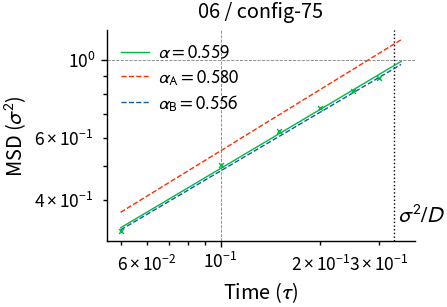

In [17]:
color = "C:g"
color_a = "C:r"
color_b = "C:b"

fig, ax = plt.subplots(figsize=(2.3, 1.6))

x = np.arange(len(msd)) * frame_interval
y = msd
ax.scatter(x, y, s=3, marker="x", color=color, zorder=5)

x = powerlaw_x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
y = powerlaw_y = x**alpha * beta
s = r"$ \alpha = %.3f $" % alpha
ax.plot(x, y, color=color, label=s, zorder=4)

if selector_a.sum() > 0:
    x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
    y = x**alpha_a * beta_a
    s = r"$ \alpha_\mathrm{A} = %.3f $" % alpha_a
    ax.plot(x, y, color=color_a, ls="--", label=s, zorder=3)

if selector_b.sum() > 0:
    x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
    y = x**alpha_b * beta_b
    s = r"$ \alpha_\mathrm{B} = %.3f $" % alpha_b
    ax.plot(x, y, color=color_b, ls="--", label=s, zorder=3)


x = diffusion_timescale
y = powerlaw_y.min()
s = r" $ \sigma^2 / D $"
ax.text(x, y, s, ha="left", va="bottom")
ax.axvline(x, ls=":", zorder=2)

ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")
ax.set_title(f"06 / config-{config_id}")
ax.legend()

ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, zorder=1)

set_axis(ax, "left bottom")

pass

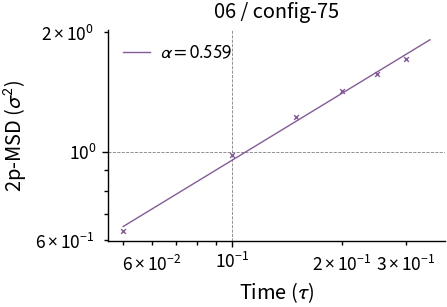

In [18]:
color = "C:m"

fig, ax = plt.subplots(figsize=(2.3, 1.6))

x = np.arange(len(pair_msd)) * frame_interval
y = pair_msd
ax.scatter(x, y, s=3, marker="x", color=color, zorder=5)

x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
y = x**pair_alpha * pair_beta
s = r"$ \alpha = %.3f $" % alpha
ax.plot(x, y, color=color, label=s, zorder=4)

ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"2p-MSD ($ \sigma^2 $)")
ax.set_title(f"06 / config-{config_id}")
ax.legend()

ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, zorder=1)

set_axis(ax, "left bottom")

pass